This notebook performs a comprehensive analysis of the "Students Performance in Exams" dataset, focusing on how demographic factors (such as gender, race/ethnicity, and parental education) influence student performance. The analysis revealed that the most influential factors affecting student performance were parental education, lunch type, and test preparation. Students whose parents had higher education levels, who had standard lunch, and who completed test preparation scored significantly higher on average.

### Libraries Used:
- **Pandas**: For data manipulation and cleaning.
- **NumPy**: For numerical operations.
- **Matplotlib**: For data visualization (e.g., plots).
- **Seaborn**: For enhanced data visualization (e.g., boxplots, histograms).
- **Scipy.stats**: For statistical tests (e.g., t-test, ANOVA).
- **Statsmodels**: For statistical modeling (e.g., regression analysis, variance inflation factor).
- **Scikit-learn**: For building and evaluating linear regression models.


### Key steps performed:

*   **Data Loading and Inspection:**
    *   The dataset was loaded using pandas.
    *   The first few rows were examined to get an understanding of the data structure, including the features related to student scores (math, reading, and writing), and socio-demographic information (gender, race/ethnicity, parental education, lunch type, and test preparation).

<p></p>

*   **Data Preprocessing:**
    *   Several variables were renamed to avoid issues in further analysis.
    
<p></p>

*   **Data Transformation:**
    *   A new variable, **average_score**, was calculated by averaging the scores in math, reading, and writing for each student.

<p></p>

*   **Exploratory Data Analysis (EDA):**
    *   Basic statistical analysis was performed to understand the distribution of the scores and demographic variables.
    *   Visualizations, including box plots and histograms, were created to explore the distribution and potential relationships between variables.

<p></p>

*   **Statistical Tests:**
    *   **T-test:** A t-test was performed to compare the means of two groups (e.g., gender or type of lunch) and determine if there were statistically significant differences in average scores between them.
    *   **ANOVA:** An ANOVA test was conducted to assess if there were significant differences in average scores across multiple categories (e.g., parental education levels or race/ethnicity).

<p></p>

*   **Model Fitting:**
    *   A **linear regression model** was built to predict the **average_score** based on the demographic features.
    *   Model fitting included checking assumptions related to linearity



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [1]:
import kagglehub
spscientist_students_performance_in_exams_path = kagglehub.dataset_download('spscientist/students-performance-in-exams')

print('Data source import complete.')

Using Colab cache for faster access to the 'students-performance-in-exams' dataset.
Data source import complete.


In [ ]:
df = pd.read_csv('/kaggle/input/students-performance-in-exams/StudentsPerformance.csv')

In [ ]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df['Average_score'] = df[['math score','reading score','writing score']].mean(axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race/ethnicity               1000 non-null   object 
 2   parental level of education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test preparation course      1000 non-null   object 
 5   math score                   1000 non-null   int64  
 6   reading score                1000 non-null   int64  
 7   writing score                1000 non-null   int64  
 8   Average_score                1000 non-null   float64
dtypes: float64(1), int64(3), object(5)
memory usage: 70.4+ KB


In [ ]:
df.describe()

,math score,reading score,writing score,Average_score
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,67.770667
std,15.16308,14.600192,15.195657,14.257326
min,0.00000,17.000000,10.000000,9.000000
25%,57.00000,59.000000,57.750000,58.333333
50%,66.00000,70.000000,69.000000,68.333333
75%,77.00000,79.000000,79.000000,77.666667
max,100.00000,100.000000,100.000000,100.000000


### Descriptive Statistics of Math, Reading, and Writing Scores

The following summary statistics were calculated for the three subjects: `Math Score`, `Reading Score`, and `Writing Score`.

- **Math Scores**:
  - **Mean**: The average math score is 66, indicating a moderate overall performance across all students.
  - **Standard Deviation (std)**: The standard deviation is 15.16, which suggests a considerable spread in the math scores.
  - **Min**: The lowest math score is 0, indicating that some students may have scored poorly.
  - **25th Percentile (25%)**: 25% of students scored below 57 in math.
  - **50th Percentile (Median, 50%)**: The median math score is 66, meaning that half of the students scored below this value, and half scored above.
  - **75th Percentile (75%)**: 75% of students scored below 77 in math, indicating that the top 25% scored higher than 77.
  - **Max**: The highest possible score of 100 is the maximum score achieved in the dataset.
<p></p>     
- **Reading Scores**:
  - **Mean**: The average reading score is 69.16, which is slightly higher than the math scores.
  - **Standard Deviation (std)**: The reading score has a standard deviation of 14.60, which indicates a slightly lower level of spread as the math scores.
  - **Min**: The lowest reading score is 17, which is higher than the lowest math score.
  - **25th Percentile (25%)**: 25% of students scored below 59 in reading.
  - **50th Percentile (Median, 50%)**: The median reading score is 70, meaning that half of the students scored below 70, and half scored above it.
  - **75th Percentile (75%)**: 75% of students scored below 79 in reading.
  - **Max**: The highest reading score is 100, which is the same as in math.
<p></p>
- **Writing Scores**:
  - **Mean**: The average writing score is 68.05, which is close to the reading score.
  - **Standard Deviation (std)**: The standard deviation of 15.19 suggests an almost similar spread in writing scores compared to math and reading.
  - **Min**: The lowest writing score is 10.
  - **25th Percentile (25%)**: 25% of students scored below 58 in writing.
  - **50th Percentile (Median, 50%)**: The median writing score is 69, showing a relatively even distribution of scores around the median.
  - **75th Percentile (75%)**: 75% of students scored below 79 in writing.
  - **Max**: The highest writing score is 100.



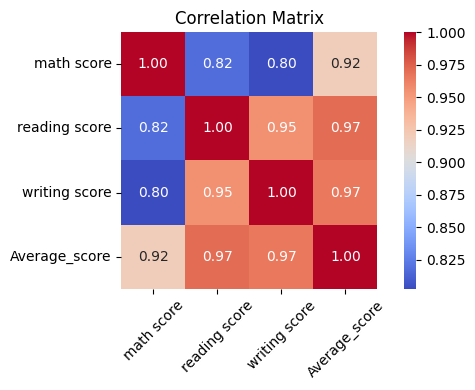

In [ ]:
def plotCorrelationMatrix(df, max_features=8):
    # Select only numeric columns
    numeric_df = df.select_dtypes(include='number')

    # Limit to top N features
    selected_df = numeric_df.iloc[:, :max_features]

    # Compute correlation matrix
    corr = selected_df.corr()

    # Plot heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
    plt.title('Correlation Matrix')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
plotCorrelationMatrix(df, max_features=8)

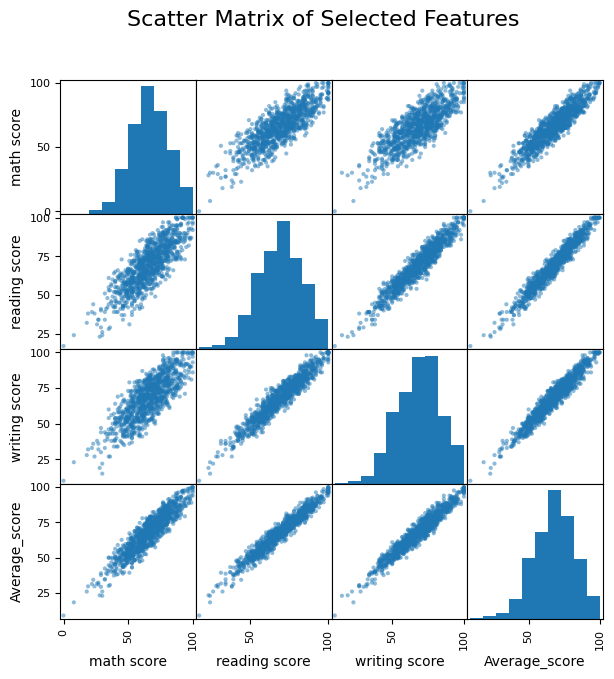

In [ ]:
from pandas.plotting import scatter_matrix

def plotScatterMatrix(df, max_features=9, figsize=6):
    numeric_df = df.select_dtypes(include='number')
    selected_df = numeric_df.iloc[:, :max_features]

    scatter_matrix(selected_df, figsize=(figsize, figsize), diagonal='hist', alpha=0.5)
    plt.suptitle("Scatter Matrix of Selected Features", fontsize=16)
    plt.show()
plotScatterMatrix(df, max_features=9, figsize=7)

All the scores show high positive correlation, meaning the students that excel in one subject tend to excel in others. Reading and writing have a high correlation. The average score is strongly driven by language skills.

In [ ]:
df = df.rename(columns={'gender' : 'Gender', \
                   'race/ethnicity' : 'Group', \
                   'parental level of education' : "Parental_education", \
                   'lunch' : 'Lunch',
                   'test preparation course' : 'Preparation_course', \
                   'math score' : 'Math_score', \
                   'reading score' : 'Reading_score', \
                   'writing score' : 'Writing_score'})

# Distribution of Scores

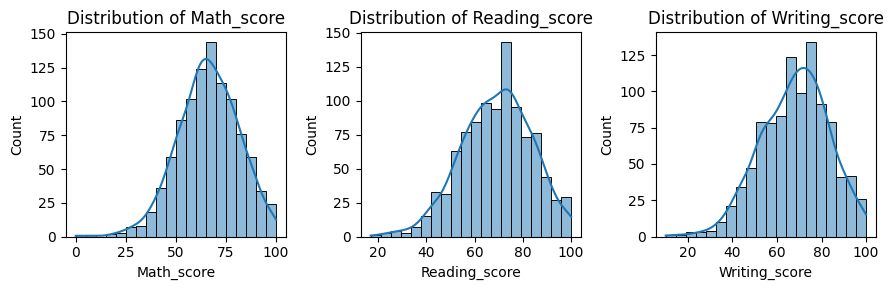

In [ ]:
plt.figure(figsize=(9, 3))

for i, subject in enumerate(['Math_score', 'Reading_score', 'Writing_score'], 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[subject], kde=True, bins=20)
    plt.title(f'Distribution of {subject}')
plt.tight_layout()
plt.show()

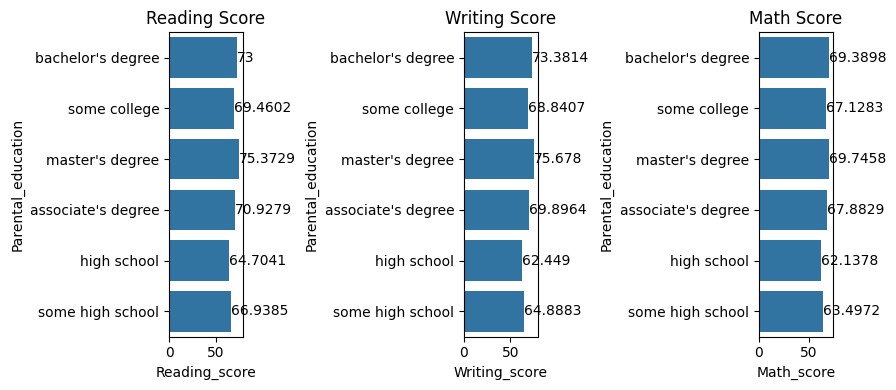

In [ ]:
_fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(9, 4))  # 3 plots side by side

# Reading Score
sns.barplot(df, y='Parental_education', x='Reading_score', orient='h', ax=axs[0], errorbar=None)
axs[0].bar_label(axs[0].containers[0], fontsize=10)
axs[0].set_title('Reading Score')

# Writing Score
sns.barplot(df, y='Parental_education', x='Writing_score', orient='h', ax=axs[1], errorbar=None)
axs[1].bar_label(axs[1].containers[0], fontsize=10)
axs[1].set_title('Writing Score')

# Math Score
sns.barplot(df, y='Parental_education', x='Math_score', orient='h', ax=axs[2], errorbar=None)
axs[2].bar_label(axs[2].containers[0], fontsize=10)
axs[2].set_title('Math Score')

plt.tight_layout()
plt.show()

We can see consistent academic advantage for students with parents holding graduate degrees with the best scores for Master's Degree across all subjects (Math: 69.74, Reading: 75.37, Writing: 75.68).

Master's > Bachelor's > Associate's > Some College > High School > Some HS

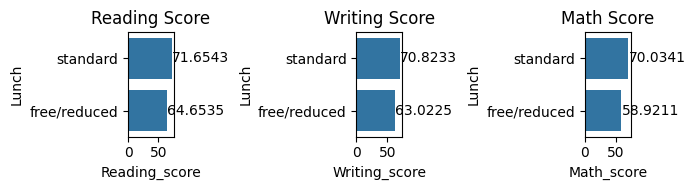

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(7, 2))  # 3 plots side by side

# Reading Score
sns.barplot(df, y='Lunch', x='Reading_score', orient='h', ax=axs[0], errorbar=None)
axs[0].bar_label(axs[0].containers[0], fontsize=10)
axs[0].set_title('Reading Score')

# Writing Score
sns.barplot(df, y='Lunch', x='Writing_score', orient='h', ax=axs[1], errorbar=None)
axs[1].bar_label(axs[1].containers[0], fontsize=10)
axs[1].set_title('Writing Score')

# Math Score
sns.barplot(df, y='Lunch', x='Math_score', orient='h', ax=axs[2], errorbar=None)
axs[2].bar_label(axs[2].containers[0], fontsize=10)
axs[2].set_title('Math Score')

plt.tight_layout()
plt.show()

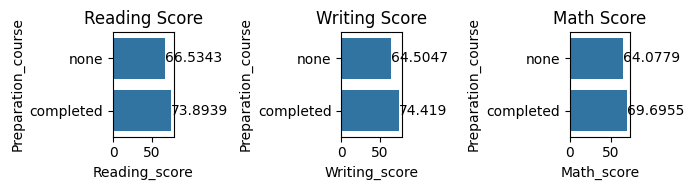

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(7, 2))  # 3 plots side by side

# Reading Score
sns.barplot(df, y='Preparation_course', x='Reading_score', orient='h', ax=axs[0], errorbar=None)
axs[0].bar_label(axs[0].containers[0], fontsize=10)
axs[0].set_title('Reading Score')

# Writing Score
sns.barplot(df, y='Preparation_course', x='Writing_score', orient='h', ax=axs[1], errorbar=None)
axs[1].bar_label(axs[1].containers[0], fontsize=10)
axs[1].set_title('Writing Score')

# Math Score
sns.barplot(df, y='Preparation_course', x='Math_score', orient='h', ax=axs[2], errorbar=None)
axs[2].bar_label(axs[2].containers[0], fontsize=10)
axs[2].set_title('Math Score')

plt.tight_layout()
plt.show()

In [ ]:
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: Gender
Gender
female    518
male      482
Name: count, dtype: int64

Column: Group
Group
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

Column: Parental_education
Parental_education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

Column: Lunch
Lunch
standard        645
free/reduced    355
Name: count, dtype: int64

Column: Preparation_course
Preparation_course
none         642
completed    358
Name: count, dtype: int64


### Categorical Variables Distribution
<p></p>

**Gender**: The dataset has a fairly balanced gender distribution, with 518 female and 482 male students.

**Race/Ethnicity**: Most students belong to Group C (319), followed by Group D (262). The smallest group is Group A with only 89 students.

**Parental Level of Education**: The majority of students' parents have completed some college (226) or have an associate's degree (222). Fewer students have parents with a master's degree (59).

**Lunch**: The majority of students receive a standard lunch (645), while 355 students receive free/reduced lunch.
<p></p>
The larger number of students receiving standard lunch suggests that the majority of the dataset represents students from families that may not qualify for free or reduced-price meals. The 355 students receiving free/reduced lunch could indicate a socioeconomic divide, where these students might come from lower-income families, and this could potentially impact their performance on the exams.
<p></p>

**Test Preparation Course**: Most students did not complete the test preparation course (642), with 358 having completed it.

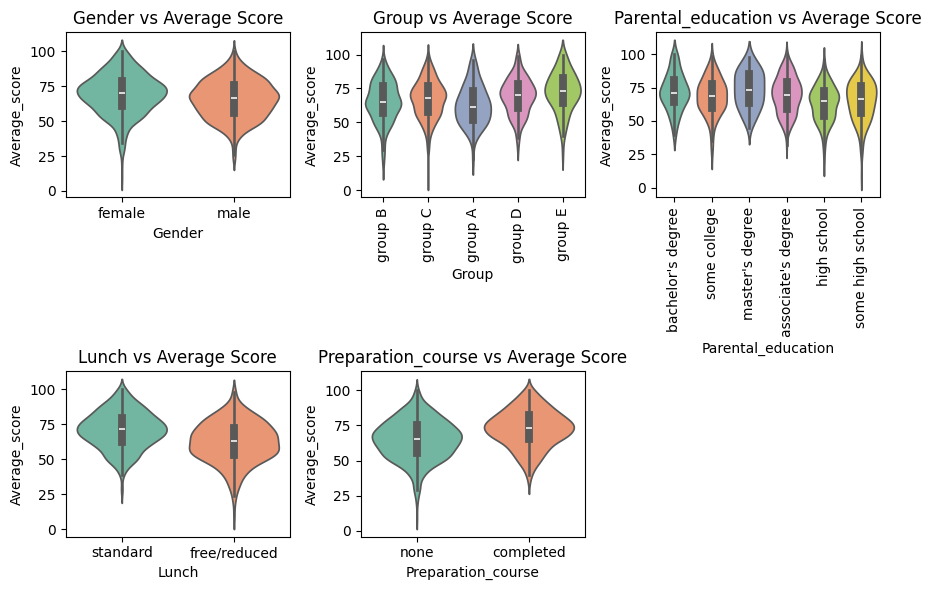

In [ ]:
# List of categorical variables to plot

categorical = ['Gender', 'Group', 'Parental_education', 'Lunch', 'Preparation_course']

# Set the size of the plots

plt.figure(figsize=(9, 6))

# Plot violin plots for each categorical variable and 'average_score'
for i, var in enumerate(categorical, 1):
    plt.subplot(2, 3, i)
    sns.violinplot(x=var, y=df['Average_score'], data=df, palette='Set2')
    plt.title(f'{var} vs Average Score')

    # Rotate x-axis labels only for 'Parental_education' and 'Group'

    if var in ['Parental_education', 'Group']:
        plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## Analysis of Average Score Distributions by Different Factors

### 1. Gender vs. Average Score

*   **Observation:** The violin plots for gender suggest a slight difference in the distribution of average scores between females and males.
*   **Interpretation:** Females seem to have a slightly higher median average score compared to males. However, the distributions overlap significantly, indicating that gender is not a strong predictor of average score.

### 2. Race/Ethnicity vs. Average Score

*   **Observation:** There appears to be some variation in average scores across different racial/ethnic groups (A, B, C, D, and E).
*   **Interpretation:** Group E appears to have a higher median average score compared to other groups, while Group A seems to have the lowest. The spread of scores also varies between groups. This suggests that race/ethnicity could be a factor influencing average scores.

### 3. Parental Level of Education vs. Average Score

*   **Observation:** There's a noticeable trend: as the parental level of education increases, the average score tends to increase as well.
*   **Interpretation:** Students whose parents have a bachelor's or master's degree generally have higher average scores compared to those whose parents have a high school education or some high school. This indicates a potential correlation between parental education and student performance. This might be linked to factors like access to resources, home environment, or parental involvement in education.

### 4. Lunch vs. Average Score

*   **Observation:** Students with standard lunch appear to have higher average scores than those with free/reduced lunch.
*   **Interpretation:** The distribution for standard lunch is shifted higher than that of free/reduced lunch. This suggests that socio-economic status, as reflected by lunch type, may play a role in academic performance. Students receiving free/reduced lunch might face challenges that affect their studies.

### 5. Test Preparation Course vs. Average Score

*   **Observation:** Students who completed the test preparation course tend to have significantly higher average scores than those who did not.
*   **Interpretation:** The violin plot for "completed" is noticeably higher than that of "none." This strongly suggests that completing the test preparation course is associated with improved performance. It could be due to better preparation, improved test-taking strategies, or increased confidence.

# Hypothesis Testing

Hypothesis Testing on student performance in different area based on different catagorical attributes.

In [ ]:
from scipy.stats import ttest_ind, f_oneway, bartlett

In [ ]:
scores = [col for col in df.select_dtypes(include = np.number).columns]

In [ ]:
from statsmodels.formula.api import ols

In [ ]:
# 1. t-test for binary categorical variables

binary_categ = ["Gender", "Lunch", "Preparation_course"]

for var in binary_categ:
    groups = df[var].unique()
    if len(groups) == 2:  # t-test only for two groups
        group1 = df[df[var] == groups[0]]["Average_score"]
        group2 = df[df[var] == groups[1]]["Average_score"]
        t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)  # Welch's t-test
        print(f"t-test for {var}: t-stat={t_stat:.3f}, p-value={p_val:.6f}")

t-test for Gender: t-stat=4.179, p-value=0.000032
t-test for Lunch: t-stat=9.323, p-value=0.000000
t-test for Preparation_course: t-stat=-8.595, p-value=0.000000


**The t-test result for gender** indicates that there is a statistically significant difference between the average scores of females and males (p-value < 0.05). This means that gender has an impact on the average score.

**The t-test for lunch** shows that there is a statistically significant difference in the average scores between students with different types of lunch (p-value < 0.05). This suggests that the type of lunch influences students' academic performance.

**The t-test for the test preparation course** variable reveals a significant difference between students who took the test preparation course and those who did not (p-value < 0.05). This indicates that taking the course has a substantial effect on the average score.


In [ ]:
# 2.ANOVA for multi-class categorical variables

multi_categ = ["Group", "Parental_education"]

for var in multi_categ:
    model = ols(f"Average_score ~ C({var})", data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(f"ANOVA for {var}:\n{anova_table}\n")

ANOVA for Group:
                 sum_sq     df         F        PR(>F)
C(Group)    7163.645895    4.0  9.096052  3.225869e-07
Residual  195904.426994  995.0       NaN           NaN

ANOVA for Parental_education:
                              sum_sq     df          F        PR(>F)
C(Parental_education)   10420.367638    5.0  10.753147  4.381046e-10
Residual               192647.705250  994.0        NaN           NaN



**The ANOVA result for race/ethnicity** shows a statistically significant difference in the average scores among students of different racial/ethnic groups (p-value < 0.05). This implies that race or ethnicity may influence academic performance.

**The ANOVA result for parental education** also indicates a significant difference in the average scores of students depending on their parents' level of education (p-value < 0.05). This suggests that parental education can have an impact on children's academic performance.

In [ ]:
# Function for visualizing numerical variables, box plot

def box_plot2(x, y, p = 'tab20'):
    ax = sns.boxplot(x = df[x], y = df[y], palette = p, showfliers = True, showmeans = True,
                     meanprops={"marker":"s","markerfacecolor":"white", "markeredgecolor":"crimson"})
    ax.set_ylabel('')
    ax.set_title('{}'.format(y), fontsize = 14, fontweight = 'bold', pad = 5)
    ax.patch.set_edgecolor('black')
    ax.patch.set_linewidth(1.5)

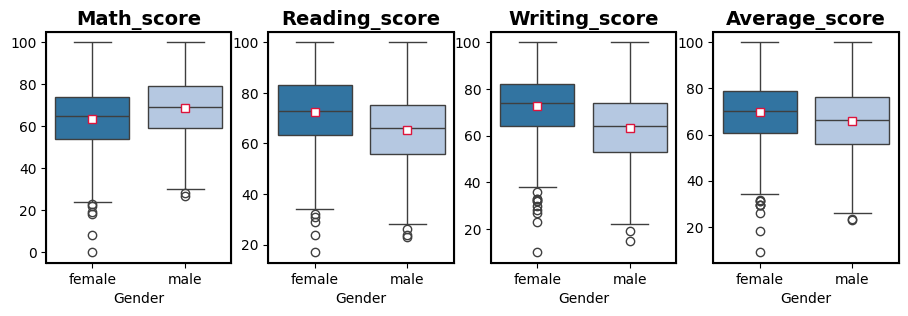

In [ ]:
plt.figure(figsize = [11, 3])
for i in range(len(scores)):
    plt.subplot(1, len(scores), i+1)
    box_plot2('Gender', scores[i]);

In [ ]:
male_scores = df[df.Gender == 'male']
female_scores = df[df.Gender == 'female']
results = pd.DataFrame(columns = ['t_statistic', 'p_value'])
for k in scores:
    t_value1,p_value1 = ttest_ind(a = male_scores[k],
                                b = female_scores[k],
                                equal_var=False)
    results.loc[k, ['t_statistic', 'p_value']] = [f"{t_value1:.4f}", f"{p_value1:.7f}"]

results

,t_statistic,p_value
Math_score,5.3980,0.0000001
Reading_score,-7.9684,0.0000000
Writing_score,-9.9977,0.0000000
Average_score,-4.1789,0.0000319


For all the three score, we obtain a p-value close to 0 from the two sample t-test. So, we can reject the null hypothesis and conclude that performance of male are female students are significantly different in all three areas. Male students and better in math while female students are better in reading and writing.

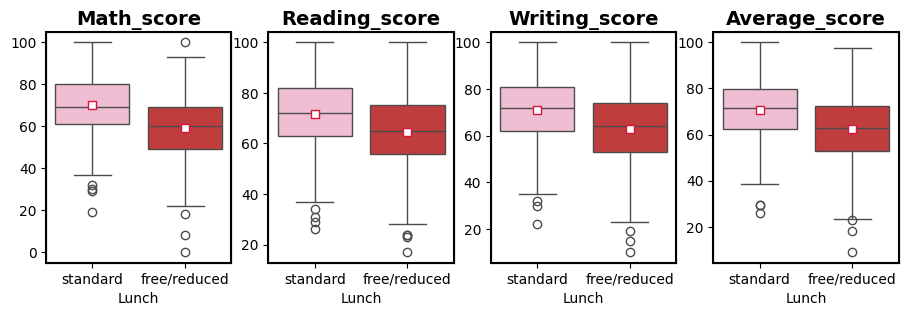

In [ ]:
plt.figure(figsize = [11, 3])
for i in range(len(scores)):
    plt.subplot(1, len(scores), i+1)
    box_plot2('Lunch', scores[i], p = 'tab20_r')

In [ ]:
standard = df[df.Lunch == 'standard']
free_reduced = df[df.Lunch == 'free/reduced']
results = pd.DataFrame(columns = ['t_statistic', 'p_value'])
for k in scores:
    t_value1,p_value1 = ttest_ind(a = standard[k],
                                b = free_reduced[k],
                                equal_var=False)
    results.loc[k, ['t_statistic', 'p_value']] = [f"{t_value1:.4f}", f"{p_value1:.10f}"]

results

,t_statistic,p_value
Math_score,11.4841,0.0000000000
Reading_score,7.2926,0.0000000000
Writing_score,7.8409,0.0000000000
Average_score,9.3232,0.0000000000


The above analysis yeilds a p-value close to zero. This indicates that students having standard lunch has a good correlation with them performing good at exams. However, it should be noted that this does not necessarily mean that there exists a causal relationship between the two

# Test Preparation Course

In [ ]:
df['Preparation_course'].value_counts()

,count
Preparation_course,
none,642
completed,358


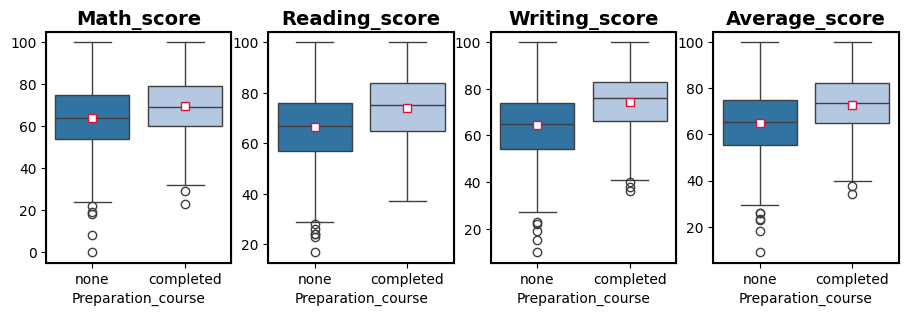

In [ ]:
plt.figure(figsize = [11, 3])
for i in range(len(scores)):
    plt.subplot(1, len(scores), i+1)
    box_plot2('Preparation_course', scores[i])


In [ ]:
none = df[df['Preparation_course'] == 'none']
completed = df[df['Preparation_course'] == 'completed']
results = pd.DataFrame(columns = ['t_statistic', 'p_value'])
for k in scores:
    t_value1,p_value1 = ttest_ind(a = none[k],
                                b = completed[k],
                                equal_var=False)
    results.loc[k, ['t_statistic', 'p_value']] = [f"{t_value1:.4f}", f"{p_value1:.10f}"]
results

,t_statistic,p_value
Math_score,-5.7870,0.0000000104
Reading_score,-8.0041,0.0000000000
Writing_score,-10.7525,0.0000000000
Average_score,-8.5945,0.0000000000


The output of the t-test here yeild a p-value close to zero. This means, that students who did complate the test preperation course had significantly better performance than the rest.

From this analysis, we can also conclude that the test preperation course is indeed effective and should be taken by students in future to improve their performance.

# Parental Level of Education

In [ ]:
df['Parental_education'].value_counts()

,count
Parental_education,
some college,226
associate's degree,222
high school,196
some high school,179
bachelor's degree,118
master's degree,59


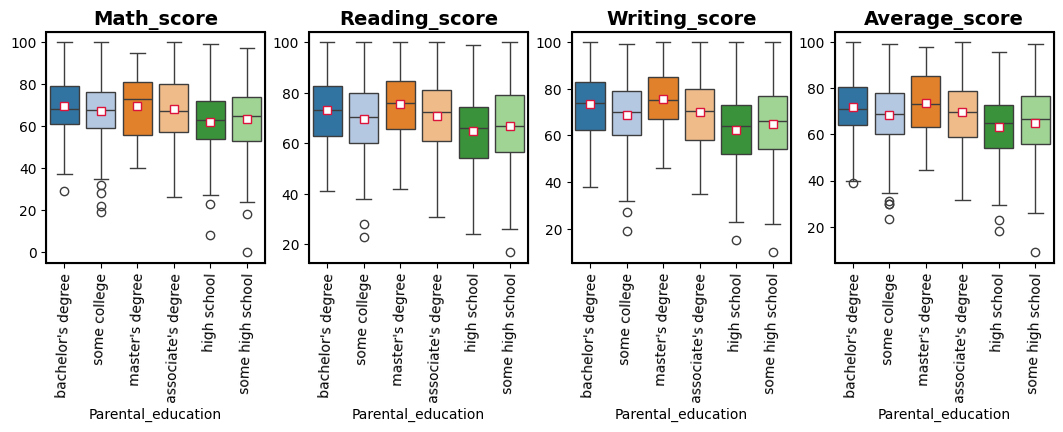

In [ ]:
plt.figure(figsize = [13, 3])
for i in range(len(scores)):
    plt.subplot(1, len(scores), i+1)
    box_plot2('Parental_education', scores[i])
    plt.xticks(rotation = 88)

In [ ]:
bachelor_deg = df[df['Parental_education'] == "bachelor's degree"]
some_col = df[df['Parental_education'] == "some college"]
masters_deg = df[df['Parental_education'] == "master's degree"]
associates_deg = df[df['Parental_education'] == "associate's degree"]
high_sch = df[df['Parental_education'] == "high school"]
some_high_sch = df[df['Parental_education'] == "some high school"]

In [ ]:
anova = pd.DataFrame(columns = ['f_statistic', 'pvalue'])
for score in scores:
    f_test = f_oneway(bachelor_deg[score], some_col[score], masters_deg[score], associates_deg[score], high_sch[score], some_high_sch[score])
    anova.loc[score, 'f_statistic'] = f_test.statistic.round(4)
    anova.loc[score, 'pvalue'] = f_test.pvalue.round(7)
anova

,f_statistic,pvalue
Math_score,6.5216,0.000006
Reading_score,9.2894,0.0
Writing_score,14.4424,0.0
Average_score,10.7531,0.0


The test result suggests the groups don't have the same sample means in this case, since the p-value is almost close to 0. This means, parent's education level does have an impact on students' performance. It's evident that the average score of student having parents with higher education is slightly better when compared to students having parents with lower level of education.

In [ ]:
X = pd.get_dummies(df[['Parental_education', 'Lunch', 'Preparation_course']], drop_first=True)

# Convert all boolean columns to 0 and 1
X = X.astype(int)

# Convert the dependent variable to numeric, replacing errors with NaN
y = pd.to_numeric(df['Average_score'], errors='coerce')


# Add a constant for the intercept
X = sm.add_constant(X)

# Build the model
model = sm.OLS(y, X).fit()

# Get the model summary
model_summary = model.summary()
print(model_summary)

                            OLS Regression Results                            
Dep. Variable:          Average_score   R-squared:                       0.204
Model:                            OLS   Adj. R-squared:                  0.198
Method:                 Least Squares   F-statistic:                     36.31
Date:                Sun, 10 Aug 2025   Prob (F-statistic):           2.36e-45
Time:                        16:53:50   Log-Likelihood:                -3961.7
No. Observations:                1000   AIC:                             7939.
Df Residuals:                     992   BIC:                             7979.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


# Task
Review and refine the provided Python code for analyzing student performance data. Specifically, enhance the linear regression model by incorporating 'Gender' and 'Group' as predictors, check for multicollinearity using VIF, and assess the model's assumptions by generating and interpreting a residual plot. The goal is to build a more robust and well-validated model.

## Refine the linear regression model

### Subtask:
Refine the linear regression model by adding 'Gender' and 'Group' as predictors to the existing model.


**Reasoning**:
 Create a new linear regression model that includes 'Gender' and 'Group' as additional predictors, one-hot encode the categorical variables, add a constant, and then fit and summarize the new OLS model. This will allow the analyzation impact of these new predictors on the average score.



In [ ]:
# 1. Create a new list of predictor variables
predictors = ['Parental_education', 'Lunch', 'Preparation_course', 'Gender', 'Group']

# 2. Use pd.get_dummies() to one-hot encode these categorical variables
X_new = pd.get_dummies(df[predictors], drop_first=True)

# 3. Convert all boolean columns to integers (0 and 1)
X_new = X_new.astype(int)

# 4. Define the independent variables (X) and the dependent variable (y)
X_new = sm.add_constant(X_new)
y_new = df['Average_score']

# 5. Build and fit a new Ordinary Least Squares (OLS) regression model
model_new = sm.OLS(y_new, X_new).fit()

# 6. Print the summary of the new model
print(model_new.summary())

                            OLS Regression Results                            
Dep. Variable:          Average_score   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.233
Method:                 Least Squares   F-statistic:                     26.30
Date:                Sun, 10 Aug 2025   Prob (F-statistic):           7.55e-52
Time:                        16:53:50   Log-Likelihood:                -3937.0
No. Observations:                1000   AIC:                             7900.
Df Residuals:                     987   BIC:                             7964.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


## Check for multicollinearity

### Subtask:
Calculate the Variance Inflation Factor (VIF) for each predictor in the refined model to check for multicollinearity.


**Reasoning**:
To check for multicollinearity,import the variance_inflation_factor function and then calculate the VIF for each predictor in the X_new dataframe, then store and display these VIF values in a new dataframe to easily interpret the results.



In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X_new.columns

vif_data["VIF"] = [variance_inflation_factor(X_new.values, i)
                          for i in range(len(X_new.columns))]

print(vif_data)

                                 feature        VIF
0                                  const  20.208522
1   Parental_education_bachelor's degree   1.353800
2         Parental_education_high school   1.528802
3     Parental_education_master's degree   1.202680
4        Parental_education_some college   1.568481
5    Parental_education_some high school   1.505924
6                         Lunch_standard   1.005618
7                Preparation_course_none   1.016140
8                            Gender_male   1.013387
9                          Group_group B   2.563889
10                         Group_group C   3.174126
11                         Group_group D   2.940722
12                         Group_group E   2.253226


## Assess model assumptions

### Subtask:
Assess the refined model's assumptions by generating and interpreting a residual plot.


**Reasoning**:
Generate and plot the residuals against the fitted values to assess the model assumptions.



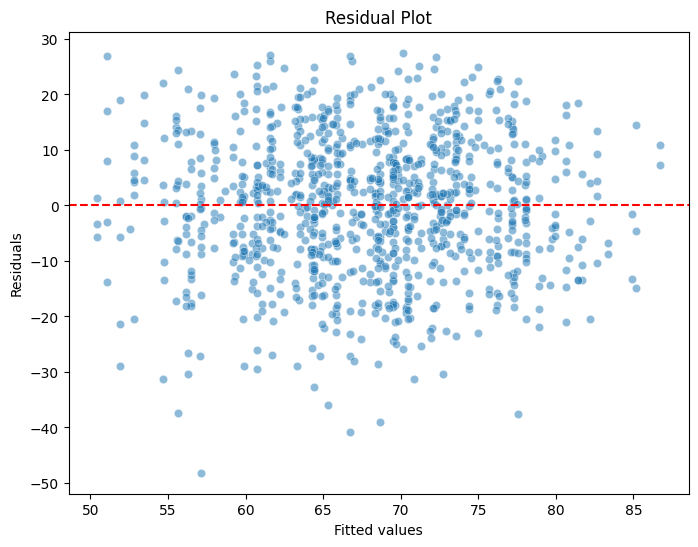

In [ ]:
# Generate residuals and fitted values
residuals = model_new.resid
fitted_values = model_new.fittedvalues

# Create the residual plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

## Summary:

### Data Analysis Key Findings

*   The refined linear regression model, including 'Gender' and 'Group' as predictors, has an R-squared value of 0.242, explaining approximately 24.2% of the variance in the average score.
*   'Gender\_male' and several 'Group' categories (specifically Group D and E) are statistically significant predictors of student performance in the refined model.
*   The Variance Inflation Factor (VIF) values for all predictors in the refined model are low (most below 5 or 10), indicating no significant multicollinearity issues.
*   The residual plot analysis suggests that the assumptions of linearity, homoscedasticity (constant variance), and independence of residuals are met for the refined model, as the residuals are randomly scattered around zero with consistent spread.

### Insights or Next Steps

*   The inclusion of 'Gender' and 'Group' improved the model's explanatory power and identified significant demographic factors influencing student performance.
*   Further analysis could explore interaction effects between the predictors to uncover more complex relationships in the data.


In [ ]:
model2 = smf.ols('Average_score ~ Parental_education * Preparation_course', data=df)
results2 = model2.fit()
print(results2.summary())

                            OLS Regression Results                            
Dep. Variable:          Average_score   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.108
Method:                 Least Squares   F-statistic:                     11.95
Date:                Sun, 10 Aug 2025   Prob (F-statistic):           2.89e-21
Time:                        16:53:51   Log-Likelihood:                -4013.3
No. Observations:                1000   AIC:                             8051.
Df Residuals:                     988   BIC:                             8109.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                                                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

### Interpretation of OLS Model 2 Results

The second OLS model investigates the interaction between `Parental_education` and `Preparation_course` on the `Average_score`.

**Model Fit:**

*   **R-squared:** The R-squared value is 0.117, indicating that approximately 11.7% of the variance in the average score is explained by the interaction between parental education and test preparation course completion. This is a relatively low R-squared, suggesting that while these factors have some influence, other variables (as seen in the previous model) contribute more significantly to the variation in student performance.
*   **Adj. R-squared:** The adjusted R-squared is 0.108, which is very close to the R-squared, indicating that the number of predictors in this model is not excessively penalizing the fit.
*   **F-statistic:** The F-statistic is 11.95 with a p-value of 2.89e-21 (very close to 0). This indicates that the model as a whole is statistically significant, meaning that the predictors included in the model collectively have a significant impact on the average score.

**Coefficients and P-values:**

The coefficients represent the estimated change in the average score for each category relative to the baseline category (which is implicitly 'associate\'s degree' for Parental_education and 'completed' for Preparation_course since `drop_first=True` was not used in the `smf.ols` function, but rather the first level is used as the reference). The p-values indicate the statistical significance of each coefficient.

*   **Intercept (74.9390):** This is the estimated average score for students whose parents have an 'associate\'s degree' and completed the test preparation course.
*   **Parental\_education coefficients:**
    *   Compared to 'associate\'s degree', only 'high school' (-7.9747, p=0.001) and 'some high school' (-5.6014, p=0.009) show statistically significant differences in average scores. Students with parents having these education levels score lower on average.
    *   'bachelor\'s degree', 'master\'s degree', and 'some college' do not show statistically significant differences in average scores compared to 'associate\'s degree' in this model.
*   **Preparation\_course[T.none] (-8.5152, p=0.000):** Students who did not complete the test preparation course score significantly lower (by approximately 8.5 points) on average compared to those who completed it, holding parental education constant at the baseline level ('associate\'s degree').
*   **Interaction terms (e.g., Parental\_education[T.bachelor's degree]:Preparation\_course[T.none]):** These coefficients represent the *additional* effect of not completing the test preparation course for each parental education level, compared to the difference observed at the baseline parental education level ('associate\'s degree'). None of the interaction terms are statistically significant (all p-values > 0.05).

**Interpretation of Interaction:**

The non-significant interaction terms suggest that the effect of completing the test preparation course on average scores is not significantly different across the various levels of parental education. In simpler terms, while taking the test preparation course generally improves scores, the *amount* of improvement is similar regardless of the parents' education level. This is also visually supported by the point plot, where the lines for "completed" and "none" are roughly parallel across the different parental education categories.

**Conclusion for Model 2:**

This model confirms that completing the test preparation course has a statistically significant positive impact on student average scores. While parental education also has an impact (as seen in the significant coefficients for 'high school' and 'some high school'), the *interaction* between parental education and test preparation is not statistically significant. This implies that the benefit of the test preparation course is generally consistent across different parental education levels.

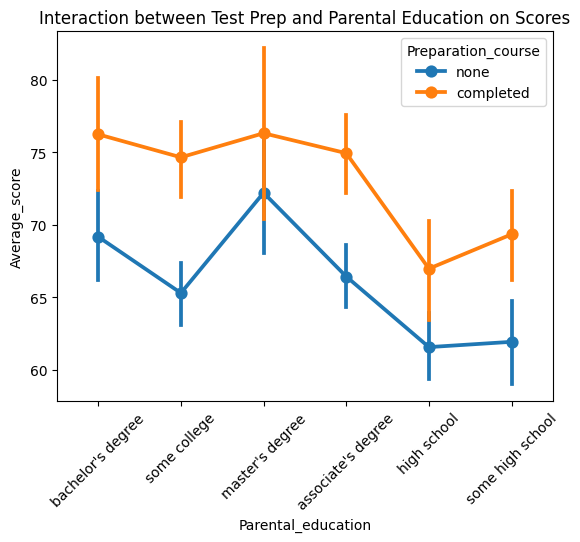

In [ ]:
sns.pointplot(data=df, x='Parental_education', y='Average_score', hue='Preparation_course')
plt.xticks(rotation=45)
plt.title("Interaction between Test Prep and Parental Education on Scores")
plt.show()